# Introducción a Series Temporales

**Elaborado por:** David Palacio J.  
**Correo:** davidpalacioj@gmail.com

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/dpalacioj/DataAI-Fundamentos-Aplicaciones/blob/main/Analitica/ciencia_datos_con_python/notebooks_teoria/08_1_intro_series_temporales.ipynb)

---

## ¿Qué es una Serie Temporal?

Una **serie temporal** es una secuencia de observaciones de una variable tomadas en momentos específicos del tiempo, generalmente a intervalos regulares.

### Ejemplos comunes:
- 📈 Precios de acciones diarios
- 🌡️ Temperaturas registradas cada hora
- 💰 Ventas mensuales de una empresa
- 📊 Número de visitantes diarios a un sitio web
- 🏥 Casos diarios de una enfermedad

### ¿Por qué son importantes?
Las series temporales nos permiten:
- **Entender patrones** históricos
- **Predecir valores futuros**
- **Detectar anomalías** o cambios estructurales
- **Tomar decisiones** basadas en tendencias

## Componentes de una Serie Temporal

Toda serie temporal se puede descomponer en varios componentes:

### 1. **Tendencia** (Trend)
- Dirección general a largo plazo de los datos
- Puede ser creciente, decreciente o constante
- Ejemplo: crecimiento poblacional a lo largo de décadas

### 2. **Estacionalidad** (Seasonality)  
- Patrones que se repiten en períodos regulares
- Ejemplo: ventas de helados (altas en verano, bajas en invierno)

### 3. **Ciclos** (Cycles)
- Fluctuaciones de largo plazo sin período fijo
- Ejemplo: ciclos económicos (recesión → crecimiento → recesión)

### 4. **Ruido/Error** (Noise/Irregular)
- Variaciones aleatorias impredecibles
- Lo que queda después de quitar tendencia, estacionalidad y ciclos

## Tipos de Descomposición

Existen dos formas principales de combinar los componentes:

### **Modelo Aditivo**: Y(t) = Tendencia + Estacionalidad + Ruido
- Los componentes se **suman**
- La estacionalidad mantiene amplitud constante
- Útil cuando las fluctuaciones estacionales no dependen del nivel de la serie

### **Modelo Multiplicativo**: Y(t) = Tendencia × Estacionalidad × Ruido
- Los componentes se **multiplican**
- La estacionalidad cambia proporcionalmente al nivel
- Útil cuando las fluctuaciones crecen con el nivel de la serie

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import seasonal_decompose

# Configuración para mejores gráficos
plt.style.use('default')
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 10

## Simulación de Datos: Comparando Estacionalidad Aditiva vs Multiplicativa

Vamos a crear dos series temporales sintéticas para entender la diferencia entre estos modelos:

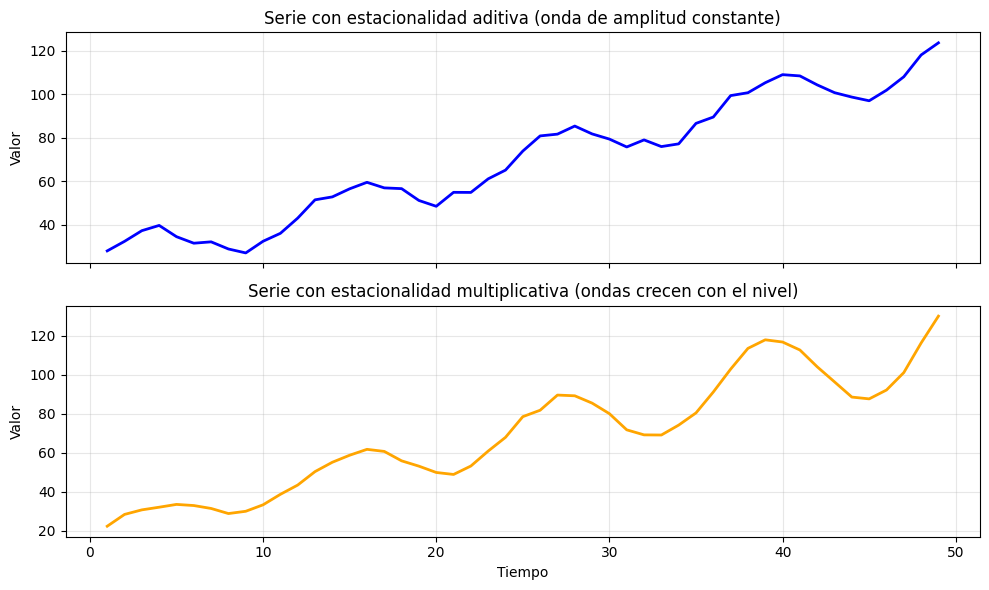

In [2]:
# Simulamos datos con tendencia creciente
np.random.seed(42)
t = np.arange(1, 50)
tendencia = t * 2 + 20  # Añadimos 20 para asegurar valores positivos

# Estacionalidad aditiva (±10)
estacional_aditiva = 10 * np.sin(2 * np.pi * t / 12)

# Estacionalidad multiplicativa (20% arriba/abajo)
estacional_multiplicativa = 1 + 0.2 * np.sin(2 * np.pi * t / 12)

# Serie aditiva
y_aditiva = tendencia + estacional_aditiva + np.random.normal(0, 2, len(t))

# Serie multiplicativa (asegurándonos de que sea positiva)
y_multiplicativa = tendencia * estacional_multiplicativa + np.random.normal(0, 1, len(t))
# Asegurar que todos los valores sean positivos
y_multiplicativa = np.maximum(y_multiplicativa, 1)  # Mínimo valor de 1

fig, ax = plt.subplots(2, 1, figsize=(10, 6), sharex=True)
ax[0].plot(t, y_aditiva, label="Aditiva", color='blue', linewidth=2)
ax[0].set_title("Serie con estacionalidad aditiva (onda de amplitud constante)")
ax[0].grid(True, alpha=0.3)
ax[0].set_ylabel("Valor")

ax[1].plot(t, y_multiplicativa, color="orange", label="Multiplicativa", linewidth=2)
ax[1].set_title("Serie con estacionalidad multiplicativa (ondas crecen con el nivel)")
ax[1].grid(True, alpha=0.3)
ax[1].set_ylabel("Valor")
ax[1].set_xlabel("Tiempo")

plt.tight_layout()
plt.show()

### Interpretación de los Gráficos

**Serie Aditiva (azul)**:
- Las oscilaciones mantienen la **misma amplitud** a lo largo del tiempo
- La estacionalidad se suma/resta independientemente del nivel de la tendencia
- Ejemplo real: temperatura diaria (varía ±10°C sin importar si estamos en enero o julio)

**Serie Multiplicativa (naranja)**:
- Las oscilaciones **crecen proporcionalmente** con la tendencia
- La estacionalidad es un porcentaje del nivel actual
- Ejemplo real: ventas navideñas (20% más que el nivel normal, pero en una empresa grande esto significa más unidades)

### ⚠️ Nota importante sobre descomposición multiplicativa

**¿Por qué la descomposición multiplicativa requiere valores positivos?**

En el modelo multiplicativo: Y(t) = Tendencia × Estacionalidad × Ruido

Para extraer los componentes, necesitamos **dividir**:
- Estacionalidad = Y(t) / Tendencia
- Ruido = Y(t) / (Tendencia × Estacionalidad)

**Si tenemos valores negativos o cero:**
- No podemos dividir por cero (matemáticamente indefinido)
- Los valores negativos generarían componentes negativos que no tienen sentido en contextos multiplicativos

Por eso ajustamos los datos para asegurar valores positivos usando `np.maximum(y_multiplicativa, 1)`.

## Descomposición de Series Temporales

La biblioteca `statsmodels` nos permite descomponer automáticamente una serie temporal en sus componentes:

In [3]:
# Crear DataFrames con fechas para mejor visualización
fechas = pd.date_range(start='2020-01-01', periods=len(t), freq='M')
serie_aditiva = pd.Series(y_aditiva, index=fechas, name='Valor')
serie_multiplicativa = pd.Series(y_multiplicativa, index=fechas, name='Valor')

print("Primeras 10 observaciones de la serie aditiva:")
print(serie_aditiva.head(10))

Primeras 10 observaciones de la serie aditiva:
2020-01-31    27.993428
2020-02-29    32.383725
2020-03-31    37.295377
2020-04-30    39.706314
2020-05-31    34.531693
2020-06-30    31.531726
2020-07-31    32.158426
2020-08-31    28.874615
2020-09-30    27.061051
2020-10-31    32.424866
Freq: M, Name: Valor, dtype: float64


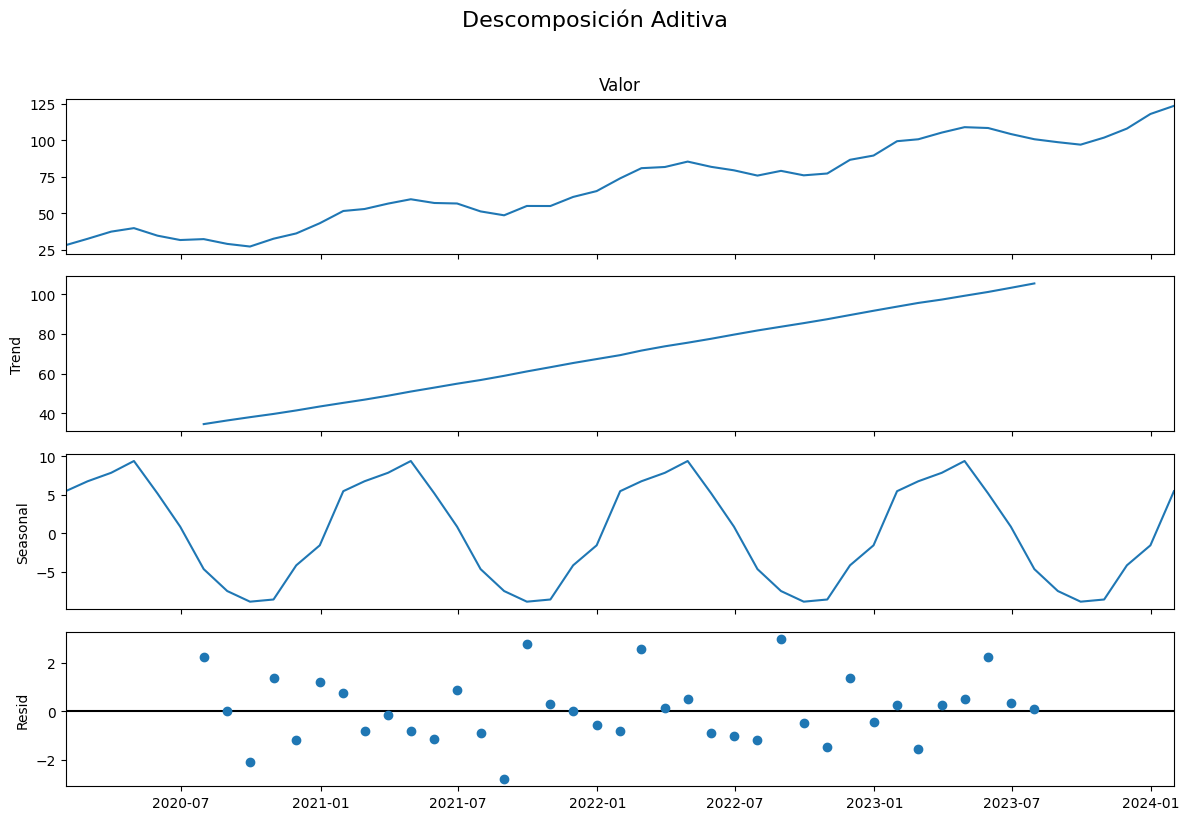

In [4]:
# Descomposición aditiva
descomp_aditiva = seasonal_decompose(serie_aditiva, model='additive', period=12)

# Visualización
fig = descomp_aditiva.plot()
fig.suptitle('Descomposición Aditiva', fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

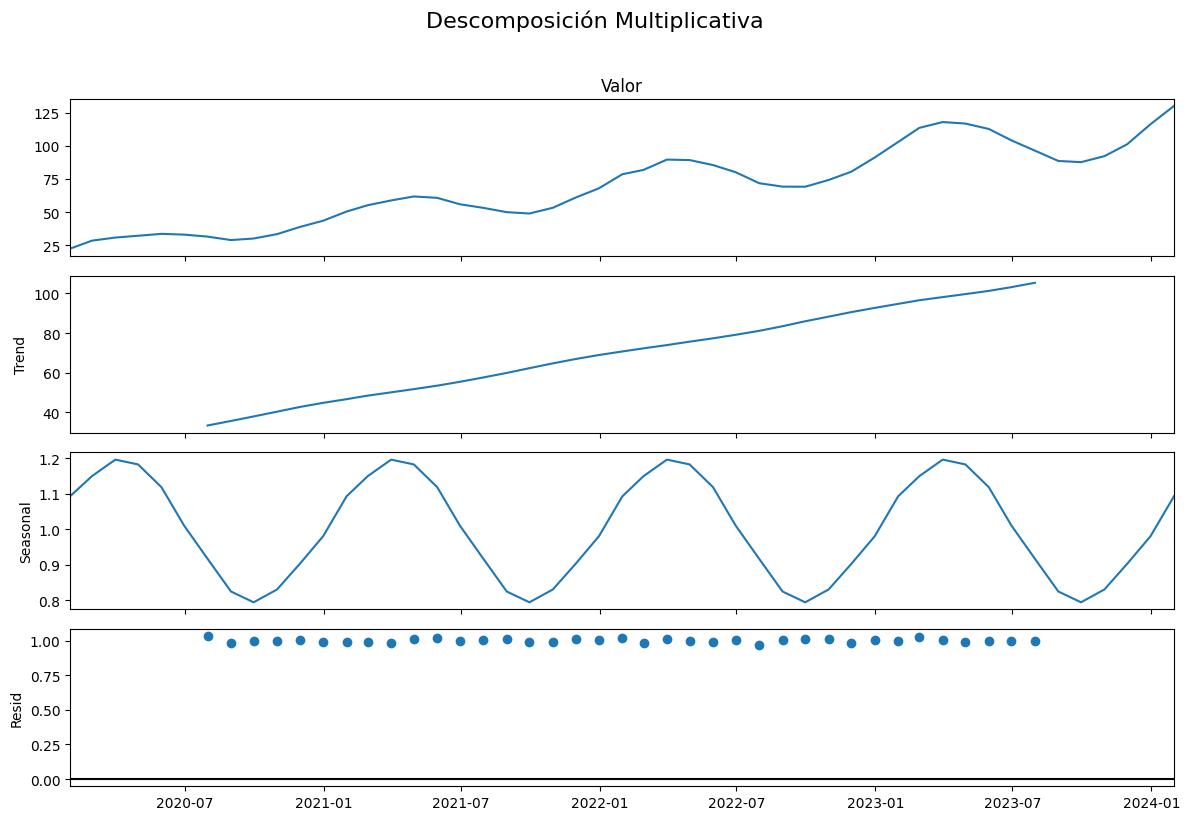

In [5]:
# Descomposición multiplicativa
descomp_multiplicativa = seasonal_decompose(serie_multiplicativa, model='multiplicative', period=12)

# Visualización
fig = descomp_multiplicativa.plot()
fig.suptitle('Descomposición Multiplicativa', fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

### Interpretación de la Descomposición

Cada gráfico muestra 4 paneles:

1. **Observed**: La serie original tal como la observamos
2. **Trend**: La tendencia subyacente (dirección general)
3. **Seasonal**: El patrón estacional que se repite
4. **Residual**: Lo que queda después de quitar tendencia y estacionalidad (ruido)

**Diferencias clave**:
- En el modelo **aditivo**, el componente estacional mantiene amplitud constante
- En el modelo **multiplicativo**, el componente estacional se expresa como proporción (valores alrededor de 1.0)

## Ejemplo Práctico: ¿Cuándo usar cada modelo?

### Usa el modelo **ADITIVO** cuando:
- Las fluctuaciones estacionales son **constantes** en términos absolutos
- Ejemplos: temperatura, precipitación, horas de luz solar
- La variabilidad no depende del nivel de la serie

### Usa el modelo **MULTIPLICATIVO** cuando:
- Las fluctuaciones estacionales **crecen proporcionalmente**
- Ejemplos: ventas, producción, turismo, datos financieros
- A mayor nivel base, mayores fluctuaciones absolutas

### Test visual simple:
- Si las "ondas" mantienen la misma altura → **ADITIVO**
- Si las "ondas" crecen con la tendencia → **MULTIPLICATIVO**

## Análisis de los Componentes

In [6]:
# Estadísticas de los componentes aditivos
print("=== MODELO ADITIVO ===")
print(f"Tendencia promedio: {descomp_aditiva.trend.mean():.2f}")
print(f"Estacionalidad - Rango: {descomp_aditiva.seasonal.max() - descomp_aditiva.seasonal.min():.2f}")
print(f"Residuales - Desv. Std: {descomp_aditiva.resid.std():.2f}")

print("\n=== MODELO MULTIPLICATIVO ===")
print(f"Tendencia promedio: {descomp_multiplicativa.trend.mean():.2f}")
print(f"Estacionalidad - Rango: {descomp_multiplicativa.seasonal.max() - descomp_multiplicativa.seasonal.min():.2f}")
print(f"Residuales - Desv. Std: {descomp_multiplicativa.resid.std():.2f}")

=== MODELO ADITIVO ===
Tendencia promedio: 69.38
Estacionalidad - Rango: 18.31
Residuales - Desv. Std: 1.37

=== MODELO MULTIPLICATIVO ===
Tendencia promedio: 70.02
Estacionalidad - Rango: 0.40
Residuales - Desv. Std: 0.01


## Aplicaciones en Machine Learning y Ciencia de Datos

### ¿Por qué es importante entender las series temporales?

1. **Feature Engineering**: 
   - Crear variables basadas en tendencia y estacionalidad
   - Detectar patrones para modelos predictivos

2. **Detección de Anomalías**:
   - Identificar valores que se desvían del patrón esperado
   - Monitoreo de sistemas en tiempo real

3. **Forecasting (Pronóstico)**:
   - Predecir valores futuros basándose en patrones históricos
   - Planificación empresarial y toma de decisiones

4. **Análisis de Impacto**:
   - Medir efectos de intervenciones o eventos
   - A/B testing en datos temporales

## Resumen de Conceptos Clave

| Concepto | Definición | Ejemplo |
|----------|------------|----------|
| **Serie Temporal** | Secuencia de datos en el tiempo | Ventas mensuales |
| **Tendencia** | Dirección general a largo plazo | Crecimiento poblacional |
| **Estacionalidad** | Patrones regulares que se repiten | Ventas navideñas |
| **Ciclos** | Fluctuaciones largas sin período fijo | Ciclos económicos |
| **Modelo Aditivo** | Y = T + S + E | Temperatura diaria |
| **Modelo Multiplicativo** | Y = T × S × E | Ventas con crecimiento |

### Próximos Pasos
- Técnicas de suavizado y filtrado
- Modelos ARIMA para pronóstico
- Machine Learning para series temporales
- Detección de cambios estructurales

### 💡 Interpretación Práctica

**Lo que nos dice el análisis estacional:**

📈 **Temporada Alta (Verano)**:
- Julio y Agosto: ~15-20% más pasajeros que el promedio
- Esto tiene sentido: vacaciones de verano, buen clima para viajar

📉 **Temporada Baja (Invierno)**:
- Febrero y Noviembre: ~10-15% menos pasajeros que el promedio
- Lógico: mal clima, menos vacaciones, gente ahorrando tras las fiestas

🔄 **Patrón Consistente**:
- Este patrón se repite cada año, pero **amplificado** por el crecimiento
- En 1949: diferencia de ~30 pasajeros entre pico y valle
- En 1960: diferencia de ~100 pasajeros entre pico y valle

**🚀 Aplicación en el Mundo Real:**
- Las aerolíneas pueden **planificar capacidad** basándose en estos patrones
- **Precios dinámicos**: más caros en julio/agosto, más baratos en febrero
- **Contratación estacional**: más personal en verano
- **Mantenimiento programado**: hacerlo en meses de menor demanda

In [ ]:
# Analicemos los componentes del modelo multiplicativo más en detalle
print("=== ANÁLISIS DEL MODELO MULTIPLICATIVO ===")
print(f"Tendencia promedio: {result_mul.trend.mean():.0f} pasajeros")
print(f"Componente estacional - Valor máximo: {result_mul.seasonal.max():.3f}")
print(f"Componente estacional - Valor mínimo: {result_mul.seasonal.min():.3f}")
print(f"Residuales - Desviación estándar: {result_mul.resid.std():.3f}")

# Veamos la estacionalidad mes a mes
print("\n=== PATRÓN ESTACIONAL MENSUAL ===")
seasonal_pattern = result_mul.seasonal.groupby(result_mul.seasonal.index.month).mean()
meses = ['Ene', 'Feb', 'Mar', 'Abr', 'May', 'Jun', 
         'Jul', 'Ago', 'Sep', 'Oct', 'Nov', 'Dic']

for i, (mes, valor) in enumerate(zip(meses, seasonal_pattern)):
    cambio = (valor - 1) * 100  # Convertir a porcentaje
    print(f"{mes}: {cambio:+5.1f}% del promedio anual")

### 🔬 Análisis Detallado de los Componentes

### 🤔 Comparando los Dos Modelos

**¿Cuál funciona mejor para estos datos?**

**Modelo Aditivo**:
- ✅ Captura bien la tendencia creciente
- ❌ Los residuales muestran patrones (no son aleatorios)
- ❌ Asume que las variaciones estacionales son constantes

**Modelo Multiplicativo**:
- ✅ Captura mejor la tendencia creciente
- ✅ Los residuales parecen más aleatorios
- ✅ Reconoce que las variaciones estacionales crecen proporcionalmente

**🎯 Conclusión:** Para datos de pasajeros de aerolíneas, el **modelo multiplicativo** es más apropiado porque:
1. Las fluctuaciones estacionales **crecen** con el nivel base
2. Es lógico: si una aerolínea transporta más gente en general, también transportará proporcionalmente más en temporada alta

In [ ]:
# Descomposición multiplicativa
result_mul = seasonal_decompose(df['Passengers'], model='multiplicative')
result_mul.plot()
plt.suptitle("Descomposición Multiplicativa - Pasajeros de Aerolíneas", fontsize=14)
plt.tight_layout()
plt.show()

In [ ]:
# Descomposición aditiva
result_add = seasonal_decompose(df['Passengers'], model='additive')
result_add.plot()
plt.suptitle("Descomposición Aditiva - Pasajeros de Aerolíneas", fontsize=14)
plt.tight_layout()
plt.show()

### 🔍 ¿Qué podemos observar en este gráfico?

**Tendencia**: 📈 Claramente creciente - cada año hay más pasajeros que el anterior  
**Estacionalidad**: 🔄 Patrones que se repiten cada año (picos en verano, valles en invierno)  
**Característica clave**: Las fluctuaciones estacionales **crecen** con el tiempo

¿Notaste que los "picos y valles" son más grandes en los años recientes? Esto es una pista de que necesitamos el modelo **multiplicativo**.

Primeras 12 observaciones del dataset:
            Passengers
Month                 
1949-01-01         112
1949-02-01         118
1949-03-01         132
1949-04-01         129
1949-05-01         121
1949-06-01         135
1949-07-01         148
1949-08-01         148
1949-09-01         136
1949-10-01         119
1949-11-01         104
1949-12-01         118

Total de observaciones: 144
Rango de fechas: 1949-01-01 00:00:00 a 1960-12-01 00:00:00


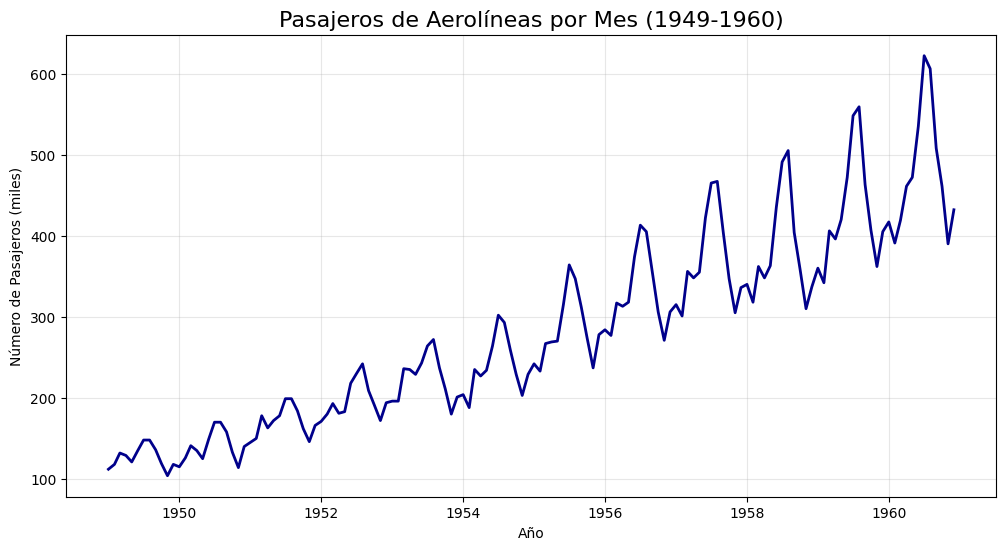

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import seasonal_decompose

# Datos de ejemplo: pasajeros de aerolíneas (famoso dataset)
url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/airline-passengers.csv"
df = pd.read_csv(url, parse_dates=['Month'], index_col='Month')

# Veamos los primeros valores para entender los datos
print("Primeras 12 observaciones del dataset:")
print(df.head(12))
print(f"\nTotal de observaciones: {len(df)}")
print(f"Rango de fechas: {df.index.min()} a {df.index.max()}")

# Grafiquemos la serie original
plt.figure(figsize=(12, 6))
plt.plot(df.index, df['Passengers'], linewidth=2, color='darkblue')
plt.title('Pasajeros de Aerolíneas por Mes (1949-1960)', fontsize=16)
plt.xlabel('Año')
plt.ylabel('Número de Pasajeros (miles)')
plt.grid(True, alpha=0.3)
plt.show()

## 🛩️ Ejemplo Práctico con Datos Reales: Pasajeros de Aerolíneas

Vamos a analizar un dataset famoso en el mundo de series temporales: el número de pasajeros de aerolíneas por mes desde 1949 hasta 1960.

Este ejemplo nos ayudará a entender mejor cuándo usar cada tipo de descomposición con datos del mundo real.